# 4.4 Implicit Problems (Parameter Estimation): Linear  Equations

In [7]:
using LinearSolve
using CairoMakie
using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

So far, in this course, we have looked at modelling data with mathematical models  where the output of the models can be evaluated explicitly.  For example

$f_{model}(x)=a_0+a_1x+a_2x^2$ or

$f_{model}(x,y)=a_0+a_1x+a_2y+a_3xy+a_4x^2$ 

If we know the values of $x,y,a_0,a_1....$, we can explicitly calculate the value of $f_{model}$.


In scientific applications, this is often not the case. In many scientific applications, the unknowns of the problem is given implicitly.  We need to solve some kind of equations to find out the output of the model.  For example, in the first week of this course, we investigated the linear system shown below 

### Linear Equations

Example of linear set of equations is given in the circuit diagram below

![Local image](../figures/01p04Fig01.png)

Applying Kirchoff’s voltage law gives

$R_1i_1+R_2i_2=V_1$

$-R_2i_2+R_3i_3+R_4i_4=0$

$R_4i_4-R_5i_5=V_2$

We also know that

$i_1-i_2-i_3=0$

$i_3-i_4-i_5=0$

We would like to solve for the unknowns $i_1$, $i_2$, $i_3$, $i_4$ and $i_5$.   So here, the input to this problem are $R_1, R_2...., R_5$ and $V_1$, and $V_1$.  The outputs are $i_1$, $i_2$, $i_3$, $i_4$ and $i_5$.  In order to get $i_1$, $i_2$, $i_3$, $i_4$ and $i_5$ we need to solve the matrix equation

$$\begin{bmatrix}
   {R_1} & {R_2} & {0}    & {0} & {0}       \\
   {0} & -{R_2} & {R_3}    & {R_4}  & {0}     \\
   {0} & {0} & {0}  & {R_4}  & -{R_5}   \\
   {1} & {-1} & {-1} & {0}  & {0}  \\
{0} & {0} & {1} & {-1}  & {-1}  \\
\end{bmatrix}\begin{Bmatrix}
i_1\\
i_2\\
i_3\\
i_4\\
i_5\\
\end{Bmatrix}= \begin{Bmatrix}
V_1\\
0\\
V_2\\
0\\
0\\
\end{Bmatrix}$$

In [24]:
R₁=5.0
R₂=150.0
R₃=100.0
R₄=250.0
R₅=200.0

V₁=100.0
V₂=50.0

A=[R₁ R₂ 0 0 0;
  0 -R₂ R₃ R₄ 0;
  0 0 0 R₄ -R₅;
  1.0 -1.0 -1.0 0 0;
  0 0 1.0 -1.0 -1.0]

C₁=[V₁, 0, V₂, 0, 0] #C1 is a (5x1) column vector
C₂=[V₁  0  V₂  0  0] #C2 is a (1x5) row matrix


1×5 Matrix{Float64}:
 100.0  0.0  50.0  0.0  0.0

To solve this set of equations, you can use the \ operator.  This is the "lazy" way and can be quite slow once you get to more complex and bigger set of equations.  

In [25]:
@time i=A\C₁

  0.001959 seconds (6 allocations: 464 bytes)


5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

In [26]:
A\C₂'

5×1 Matrix{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

You can also solve $[A]\{x\}=\{C\}$ using `LinearSolve` library.  You will find that `LinearSolve`  is usually faster than the \ operator, especially for larger system.  

In [27]:
# Define the linear problem
prob = LinearProblem(A,C₁)

# Solve the problem using defaults
@time sol = solve(prob)

  0.000471 seconds (21 allocations: 1.688 KiB)


retcode: Success
u: 5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

In [28]:
i=sol.u

5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

Last week,  wrote a Julia program that solves for $i_5$ for $V_1\in[50,100]$ The results and plot for $i_5$ vs $V_1$ is shown below

In [29]:
A=[R₁ R₂ 0 0 0;
  0 -R₂ R₃ R₄ 0;
  0 0 0 R₄ -R₅;
  1 -1 -1 0 0;
  0 0 1 -1 -1]

C₁=[V₁, 0, V₂, 0, 0] #C1 is a (5x1) column vector
V₁vec=50:1:100
i₅vec=zeros(length(V₁vec))
for i=1:length(V₁vec)
    C₁[1]=V₁vec[i]
    prob = LinearProblem(A,C₁)
    sol = solve(prob)
    i₅vec[i]=sol.u[5]
end

In [30]:
i₅vec

51-element Vector{Float64}:
 -0.05809128630705396
 -0.05560165975103735
 -0.05311203319502076
 -0.05062240663900415
 -0.04813278008298756
 -0.04564315352697097
 -0.04315352697095436
 -0.04066390041493779
 -0.03817427385892118
 -0.035684647302904576
  ⋮
  0.04647302904564314
  0.04896265560165975
  0.051452282157676325
  0.0539419087136929
  0.05643153526970954
  0.05892116182572615
  0.06141078838174272
  0.0639004149377593
  0.0663900414937759

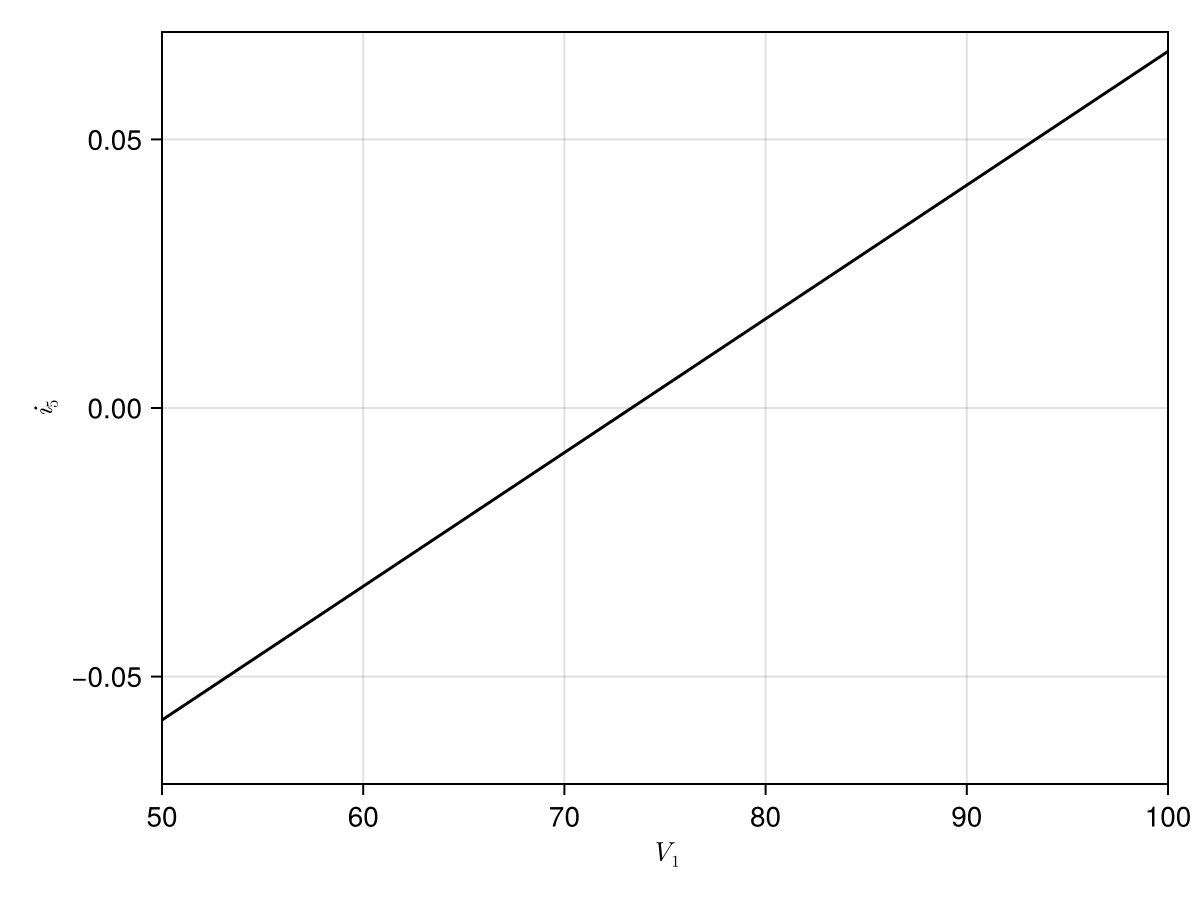

CairoMakie.Screen{IMAGE}


In [33]:
fig = Figure() #set up a figure
ax1 = Axis(fig[1, 1], xlabel = L"V_1", ylabel = L"i_5",limits=(50,100,-0.07,0.07)) #Define axis in the figure
lines!(ax1,V₁vec,i₅vec;color=:black) #Plot i_5 vs V_1
save("../figures/04p04ParameterEstimationLinearProblems03.svg",fig)
display(fig)

---

From the figure above.  $i_5$ increases with $V_1$.  There is a relationship between $i_5$  and $V_1$.  We just do not know what it is.  We need to solve the matrix equation below

$$\begin{bmatrix}
   {R_1} & {R_2} & {0}    & {0} & {0}       \\
   {0} & -{R_2} & {R_3}    & {R_4}  & {0}     \\
   {0} & {0} & {0}  & {R_4}  & -{R_5}   \\
   {1} & {-1} & {-1} & {0}  & {0}  \\
{0} & {0} & {1} & {-1}  & {-1}  \\
\end{bmatrix}\begin{Bmatrix}
i_1\\
i_2\\
i_3\\
i_4\\
i_5\\
\end{Bmatrix}= \begin{Bmatrix}
V_1\\
0\\
V_2\\
0\\
0\\
\end{Bmatrix}$$


to find $i_5$ for different values of $V_1$. 

Since we now know how $i_5$ changes with $V_1$, let's plot and see how $i_5^2$ changes with $V_1$ 


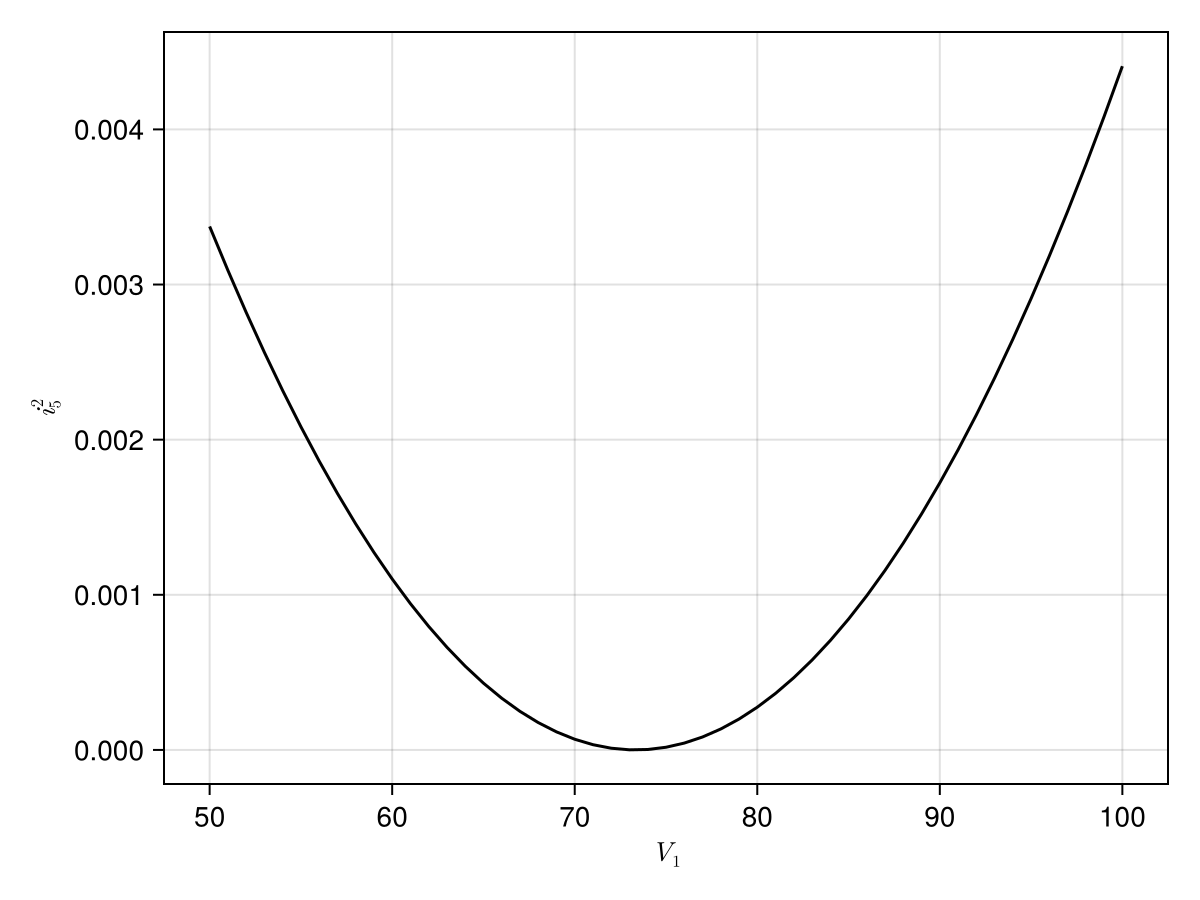

CairoMakie.Screen{IMAGE}


In [35]:
fig = Figure() #set up a figure
ax2 = Axis(fig[1, 1], xlabel = L"V_1", ylabel = L"i_5^2") #Define axis in the figure
lines!(ax2,V₁vec,i₅vec.^2;color=:black) #Plot i_5^2 vs V_1
save("../figures/04p04ParameterEstimationLinearProblems04.svg",fig)
display(fig)

We now would like to find the value of $V_1$ such that $i_5=0$.  From the graph above, we can see that  $i_5 \approx 0$ when  $V_1\approx 73$.  But what if we want to accurately find this value of $V_1$? 

We can define a loss function that calculates $i_5^2$ given $V_1$.  Note that this `loss` function has to solve the matrix equation every time it wants to calculate the `loss` function.  

In [17]:
function loss(p)
    C=[p[1],0,V₂,0,0]
    prob = LinearProblem(A,C)
    i = LinearSolve.solve(prob)
    return sum(i[end].^2)
end

loss (generic function with 1 method)

Check if the loss function gives sensible values (can check the value of $i_5$ when $V_1=91$ with the graph above)

In [18]:
loss([91.0])

0.0019345396945644828

Check the calculation of the gradient to see if all makes sense

In [19]:
ForwardDiff.gradient(loss,[91.0])

1-element Vector{Float64}:
 0.00021900449372428134

In [20]:
ForwardDiff.gradient(loss,[55.0])

1-element Vector{Float64}:
 -0.0002272688142421791

The gradient of the loss function is positive for $V_1=91$ and negative for $V_1=55$.  This is consistent with the graph above.  So all seems to be good.  

Now we will use  gradient descent to find the minimum of the loss function

In [21]:
iguess=60
α=100.00
for i=1:50000
    iguess-=α*ForwardDiff.gradient(loss,[iguess])[1]
end
iguess
    

73.33333333332762

Since this is an optimization problem, we can use the Optimization function in Julia to solve for $V_1$.

In [22]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

callback (generic function with 1 method)

Finding optimum value of $V_1$ using Julia SciML package. 

In [23]:
losses = Float64[]
optf = OptimizationFunction((p,x)->loss(p), AutoForwardDiff())
optprob = OptimizationProblem(optf,[80.0])
sol=Optimization.solve(optprob,Adam(0.1f0),maxiters=500,callback=callback)
#sol=Optimization.solve(optprob,Descent(0.1f0),maxiters=10000,callback=callback)

Current loss after 50 iterations: 3.411434660652598e-5
Current loss after 100 iterations: 7.073114417721967e-7
Current loss after 150 iterations: 4.453085525072283e-12
Current loss after 200 iterations: 1.353323459635135e-11
Current loss after 250 iterations: 7.927841938254818e-14
Current loss after 300 iterations: 2.4174645797258106e-16
Current loss after 350 iterations: 7.701858417961295e-19
Current loss after 400 iterations: 4.078850371888853e-21
Current loss after 450 iterations: 3.4137027700883137e-23
Current loss after 500 iterations: 2.9196134544208437e-25


retcode: Default
u: 1-element Vector{Float64}:
 73.33333333333732